# 1、导入必要的包和库，然后读取Inp文件展示节点信息。

In [1]:
#import packages
import time
import numpy as np
import capytaine as cpt
import scipy
from capytaine.io.mesh_writers import write_STL
import matplotlib.pyplot as plt
from scipy.linalg import block_diag
from scipy.linalg import eigh
import vtk
import logging
import xarray as xr
from capytaine.io.xarray import merge_complex_values
from capytaine.post_pro import rao
logging.basicConfig(level=logging.INFO, format='%(levelname)-8s: %(message)s')
# user defined functions
import DM_ShowNodes as DMshow
import DM_Reading as dm_r
import DM_Assemble as DM_A
import SEREP as SEREP

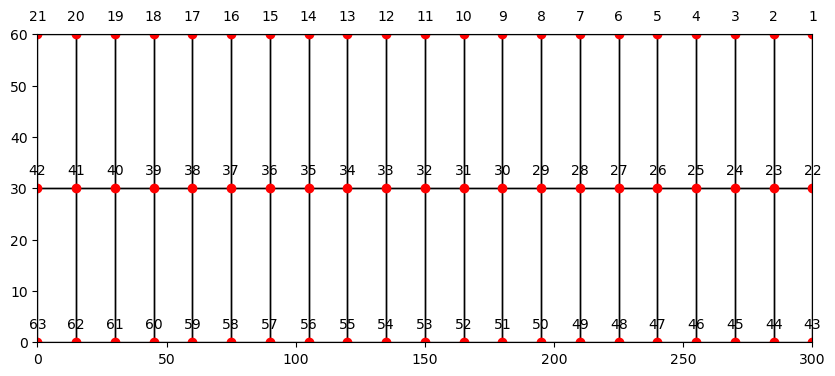

In [2]:
# Show nodes and node message
file_path = "E:\phd\Code\DM-FEM2D\Fem_inp\Job-1_largemesh.inp"
label_interval = 1
node = DMshow.plot_fea_model(file_path, label_interval)
#node_ids = [41, 39, 37, 35, 33, 31, 29, 27, 25, 23]

In [30]:
# define parameters
num_nodes = 793 # 63 793
master_nodes = DM_A.calculate_node_positions(424,6,10) #[41, 39, 37, 35, 33, 31, 29, 27, 25, 23] DM_A.calculate_node_positions(424,6,10)
dataset = merge_complex_values(xr.open_dataset("E:\phd\Code\DM-FEM2D\HydrodynamicData\Yoga\DM10_145_direction0.nc"))
omega = dataset.omega.values
# Area = 1025*9.81*30*15
# nodes_per_row = 21
# read mass and stiffness matrix
file_m = 'E:\phd\Code\DM-FEM2D\StructureData\JobMesh5_5_MASS1.mtx'
file_k = 'E:\phd\Code\DM-FEM2D\StructureData\JobMesh5_5_STIF1.mtx' 
M = dm_r.get_stiffness_matrix(file_m)
k = dm_r.get_stiffness_matrix(file_k)

# reduce dofs
M_consistant= SEREP.reduce_dofs(M, num_nodes, [5])
k = SEREP.reduce_dofs(k, num_nodes, [5])

# transform mass matrix, beta=0 is consistant mass matrix
M = SEREP.transform_mass_matrix(M_consistant,beta=0)
# obtaine master dofs and slave dofs
MasterDofs, SlaveDofs = SEREP.separate_dofs(num_nodes, master_nodes)

# reduce matrix use SEREP
MR,KR,T = SEREP.SEREP(k, M, SlaveDofs, master_nodes)
# read hydrodynamic data
added_mass = dataset['added_mass'][0].values
radiation_damping = dataset['radiation_damping'][0].values
inertia_matrix = dataset['inertia_matrix'].values
# hydrostatic_stiffness = dataset['hydrostatic_stiffness'].values
F_w = dataset['Froude_Krylov_force'][0].values + dataset['diffraction_force'][0].values
# REDUCE THE MATRICES
added_mass = SEREP.reduce_dofs(added_mass,10,[5])
radiation_damping = SEREP.reduce_dofs(radiation_damping,10,[5])
# hyrostatic stiffness or fem spring stiffness
# 1. choice hydrostatic stiffness
hydrostatic_stiffness = dataset['hydrostatic_stiffness'].values
hydrostatic_stiffness = SEREP.reduce_dofs(hydrostatic_stiffness,10,[5])
# 2. choice fem spring stiffness
# hydrostatic_stiffness = SEREP.get_fem_spring_stiffness(num_nodes, nodes_per_row, Area)
# hydrostatic_stiffness = SEREP.reduce_dofs(hydrostatic_stiffness,num_nodes,[5])
# hydrostatic_stiffness = T.T @ hydrostatic_stiffness @ T

inertia_matrix = SEREP.reduce_dofs(inertia_matrix,10,[5])
F_w = SEREP.reduce_force_matrix_dofs(F_w, 10, 5).reshape(1,50)
F_w = F_w.reshape(10,5)[::-1].reshape(1,50)
# Generate the system matrices
mass = added_mass + MR
damping = radiation_damping
stiffness =  hydrostatic_stiffness + KR
# Solve in frequency domain
master_displacement = DM_A.solve_frequency_domain(mass, damping, stiffness, F_w, omega)
# Restore global displacement under disorder masterdofs and slavedofs
global_displacement_disorder = T @ master_displacement
# Reorder global displacement under order
global_displacement = SEREP.reorder_displacement_matrix(global_displacement_disorder, MasterDofs, SlaveDofs)

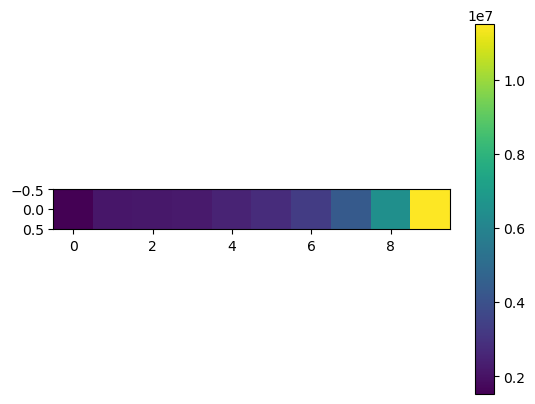

In [31]:
plt.imshow(abs(F_w[:,2::5]))
plt.colorbar()

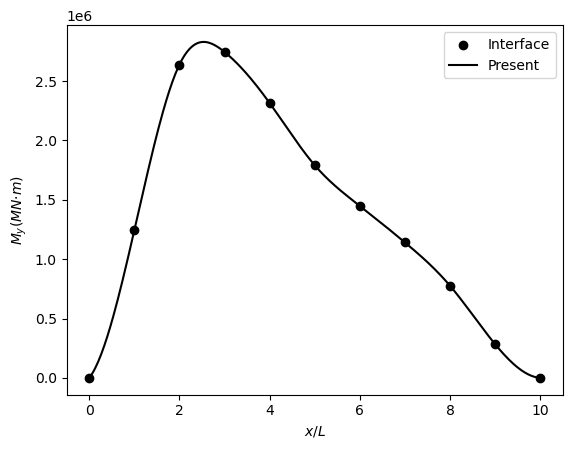

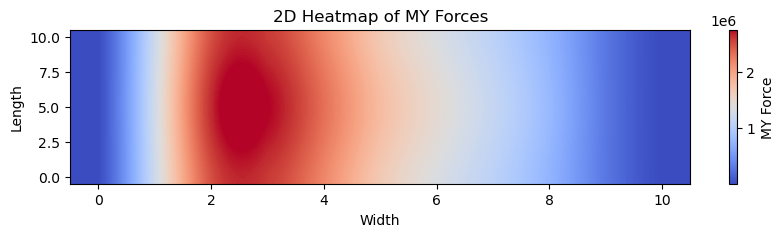

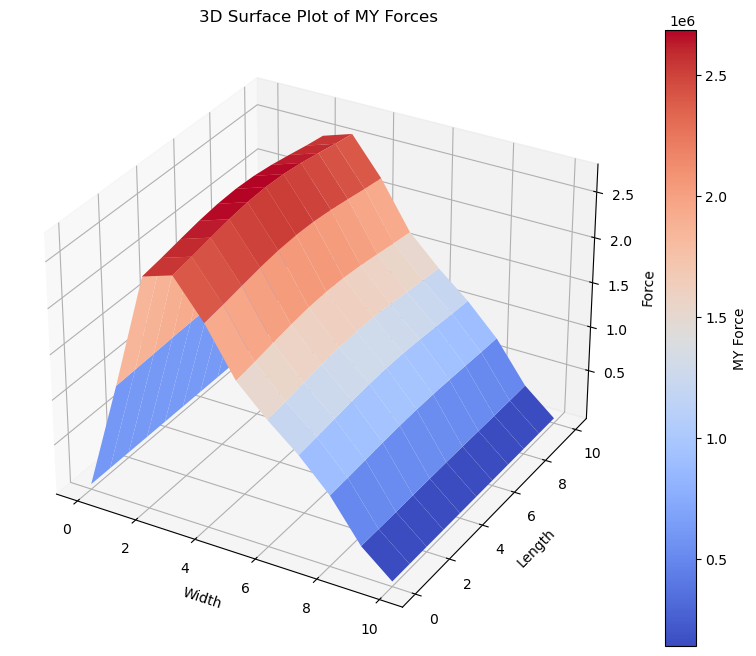

In [7]:
# Import force analysis model
from DM_forec_analysis import ForceAnalysis
# Create an instance of the ForceAnalysis class
# Parameters include:
# N: Total Number of nodes
# H: Row
# module_nodes: Number of nodes per module
# module_number: Number of modules
# element_length: Length of the element
# element_width: Width of the element
analyzer = ForceAnalysis(N=793, H=13, module_nodes=7, module_number=10, element_length=5, element_width=5, dof=5)
# analyzer = ForceAnalysis(N=63, H=3, module_nodes=3, module_number=10, element_length=15, element_width=30,dof=5)
# Compute module displacements using the provided displacement matrix X
module_displacements = analyzer.compute_module_displacements(displacement_matrix=global_displacement)

# Fetch the stiffness matrix for an element from a specified file
K_element = dm_r.get_stiffness_matrix("E:\phd\Code\DM-FEM2D\StructureData\sub_m10_w60.mtx")#E:\phd\Code\DM-FEM2D\data\model300_60\Job-1_sub-1_STIF1.mtx
K_element = SEREP.reduce_dofs(K_element, 91, [5])
# K_element = SEREP.reduce_dofs(K_element, 9, [5])

# Compute forces within the module using the stiffness matrix and module displacements
module_forces = analyzer.compute_module_forces(K_element, module_displacements)

# Map the forces from module level to global nodes
global_forces = analyzer.map_forces_to_global_nodes(module_forces)

# Visualize global forces using a plot
analyzer.plot_forces(global_forces)

# Display global forces as a 2D heatmap
analyzer.plot_2D_heatmap(global_forces)

# Display global forces as a 3D surface plot
analyzer.plot_3D_surface(global_forces)

(0.0, 3.0)

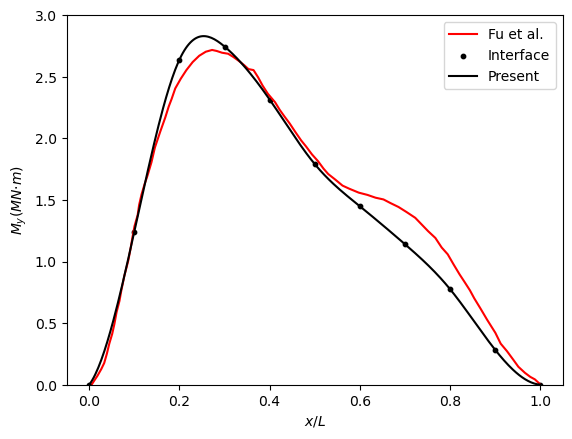

In [8]:
# 绘制内力图
from DM_Verify import process_exp_data
exp_x, exp_y = process_exp_data(r"E:\phd\Code\DM-FEM2D\data\Experiment_300_60\fig9_bm_fu.txt")
exp_y = np.array(exp_y)
data = analyzer.get_middle_interface_forces(global_forces)
x = np.arange(len(data))
y = data[:, 0]
from scipy import interpolate
spline = interpolate.CubicSpline(x, y)
x_new = np.linspace(0, len(data)-1, 300)
y_new = spline(x_new)
plt.plot(exp_x,exp_y/60,color = 'red', label = 'Fu et al.')
plt.scatter(x/10, y/1e6, color='black', s=10,label='Interface')
plt.plot(x_new/10, y_new/1e6,color ='black', label='Present')
plt.legend()
# plt.title("Scatter Plot and Cubic Spline Interpolation")
plt.xlabel(r"$x$/$L$")
plt.ylabel(r"$M_y$($MN{\cdot}m$)")
plt.ylim(0,3)

(0.0, 3.0)

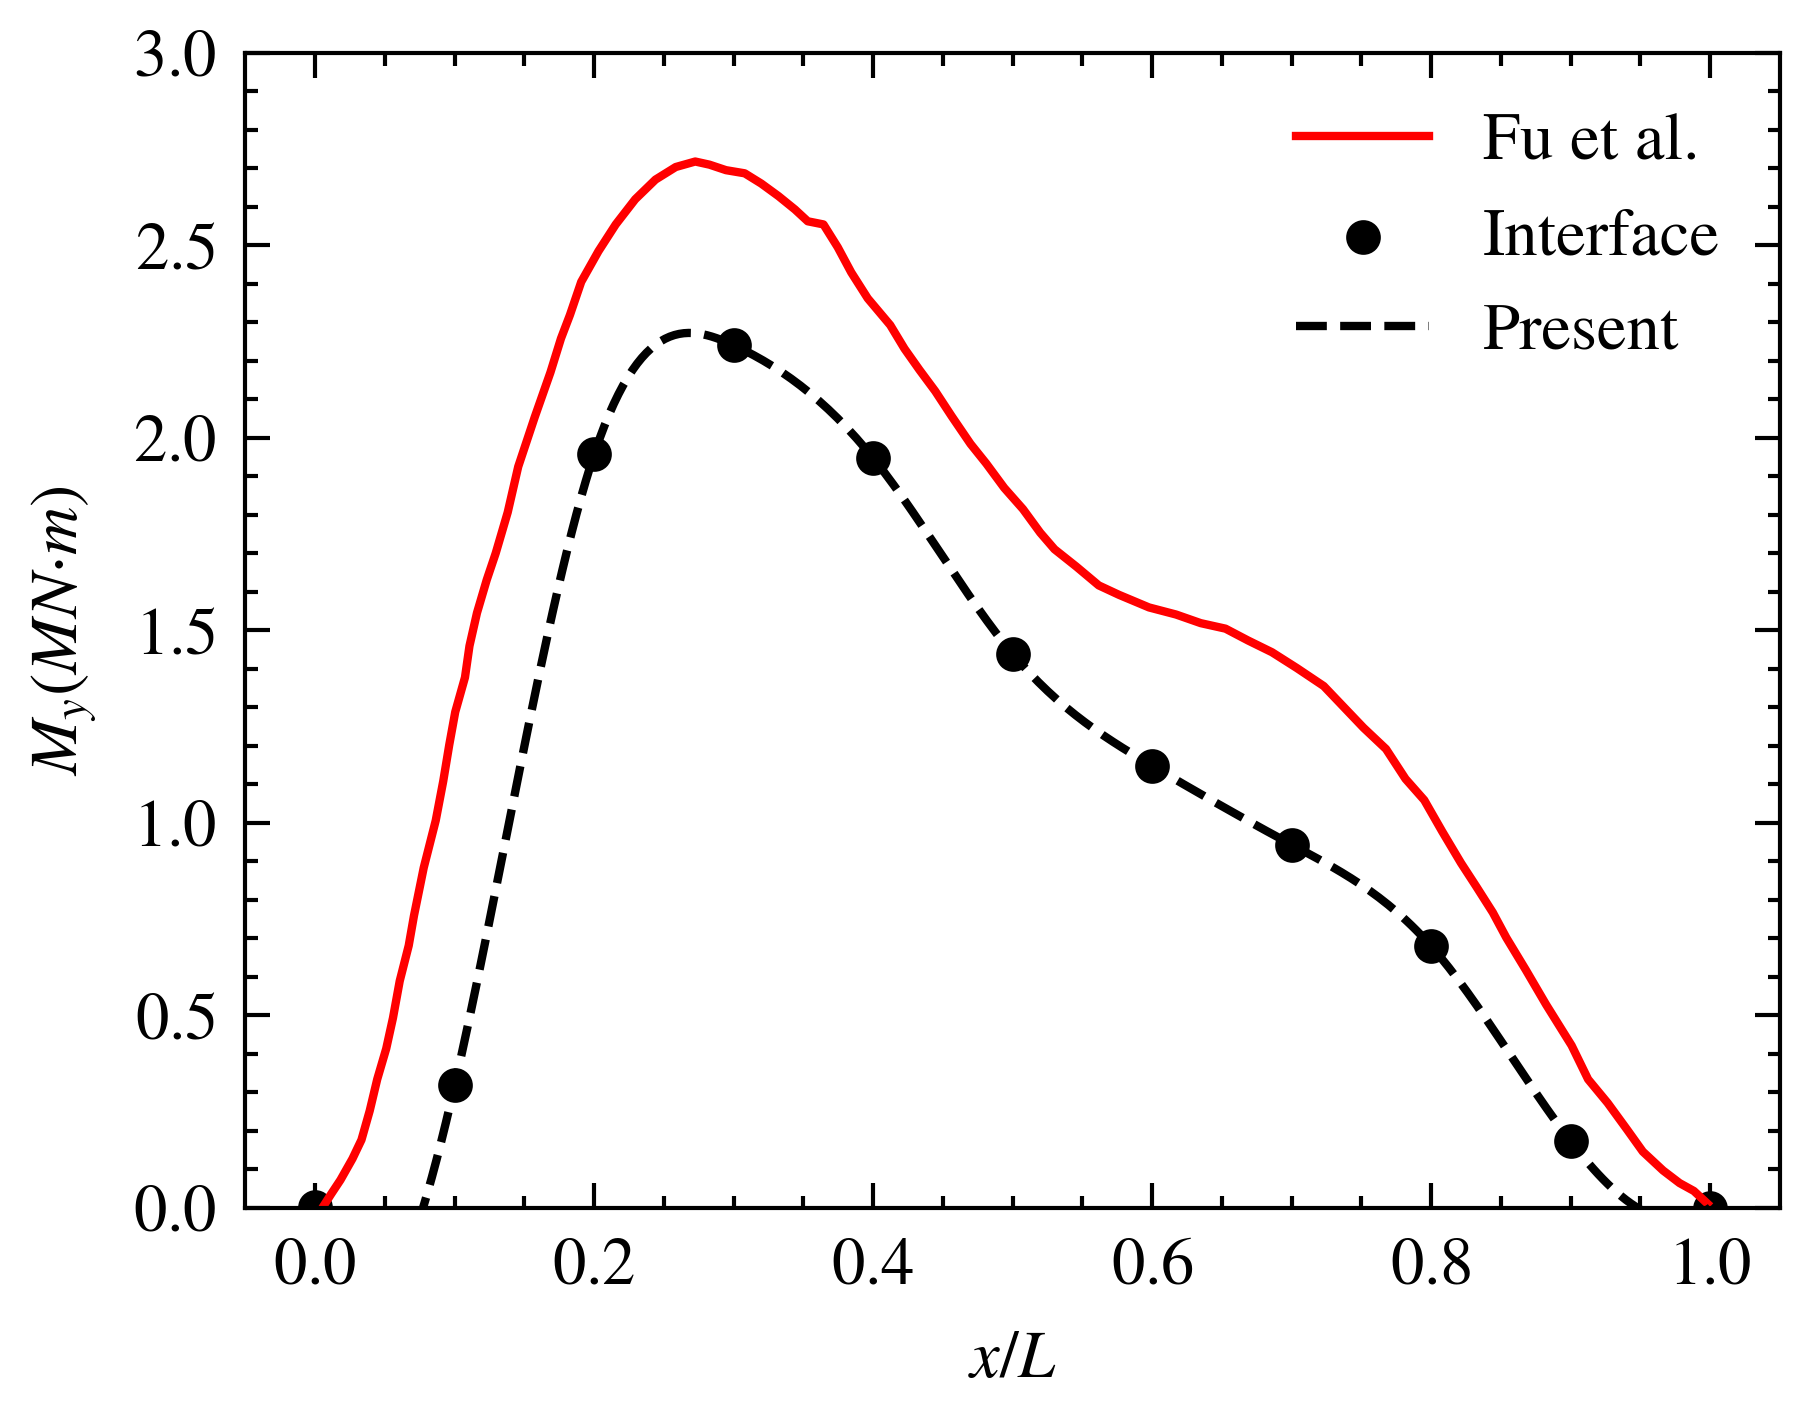

In [65]:
# 绘制内力图
from DM_Verify import process_exp_data
exp_x, exp_y = process_exp_data(r"E:\phd\Code\DM-FEM2D\data\Experiment_300_60\fig9_bm_fu.txt")
exp_y = np.array(exp_y)
data = analyzer.get_middle_interface_forces(global_forces)
x = np.arange(len(data))
y = data[:, 0]
from scipy import interpolate
spline = interpolate.CubicSpline(x, y)
x_new = np.linspace(0, len(data)-1, 300)
y_new = spline(x_new)
plt.plot(exp_x,exp_y/60,color = 'red', label = 'Fu et al.')
plt.scatter(x/10, y/1e6, color='black', s=10,label='Interface')
plt.plot(x_new/10, y_new/1e6,color ='black', label='Present')
plt.legend()
# plt.title("Scatter Plot and Cubic Spline Interpolation")
plt.xlabel(r"$x$/$L$")
plt.ylabel(r"$M_y$($MN{\cdot}m$)")
plt.ylim(0,3)

## 验证工作

Text(0, 0.5, 'Heave RAO ($m$/$m$)')

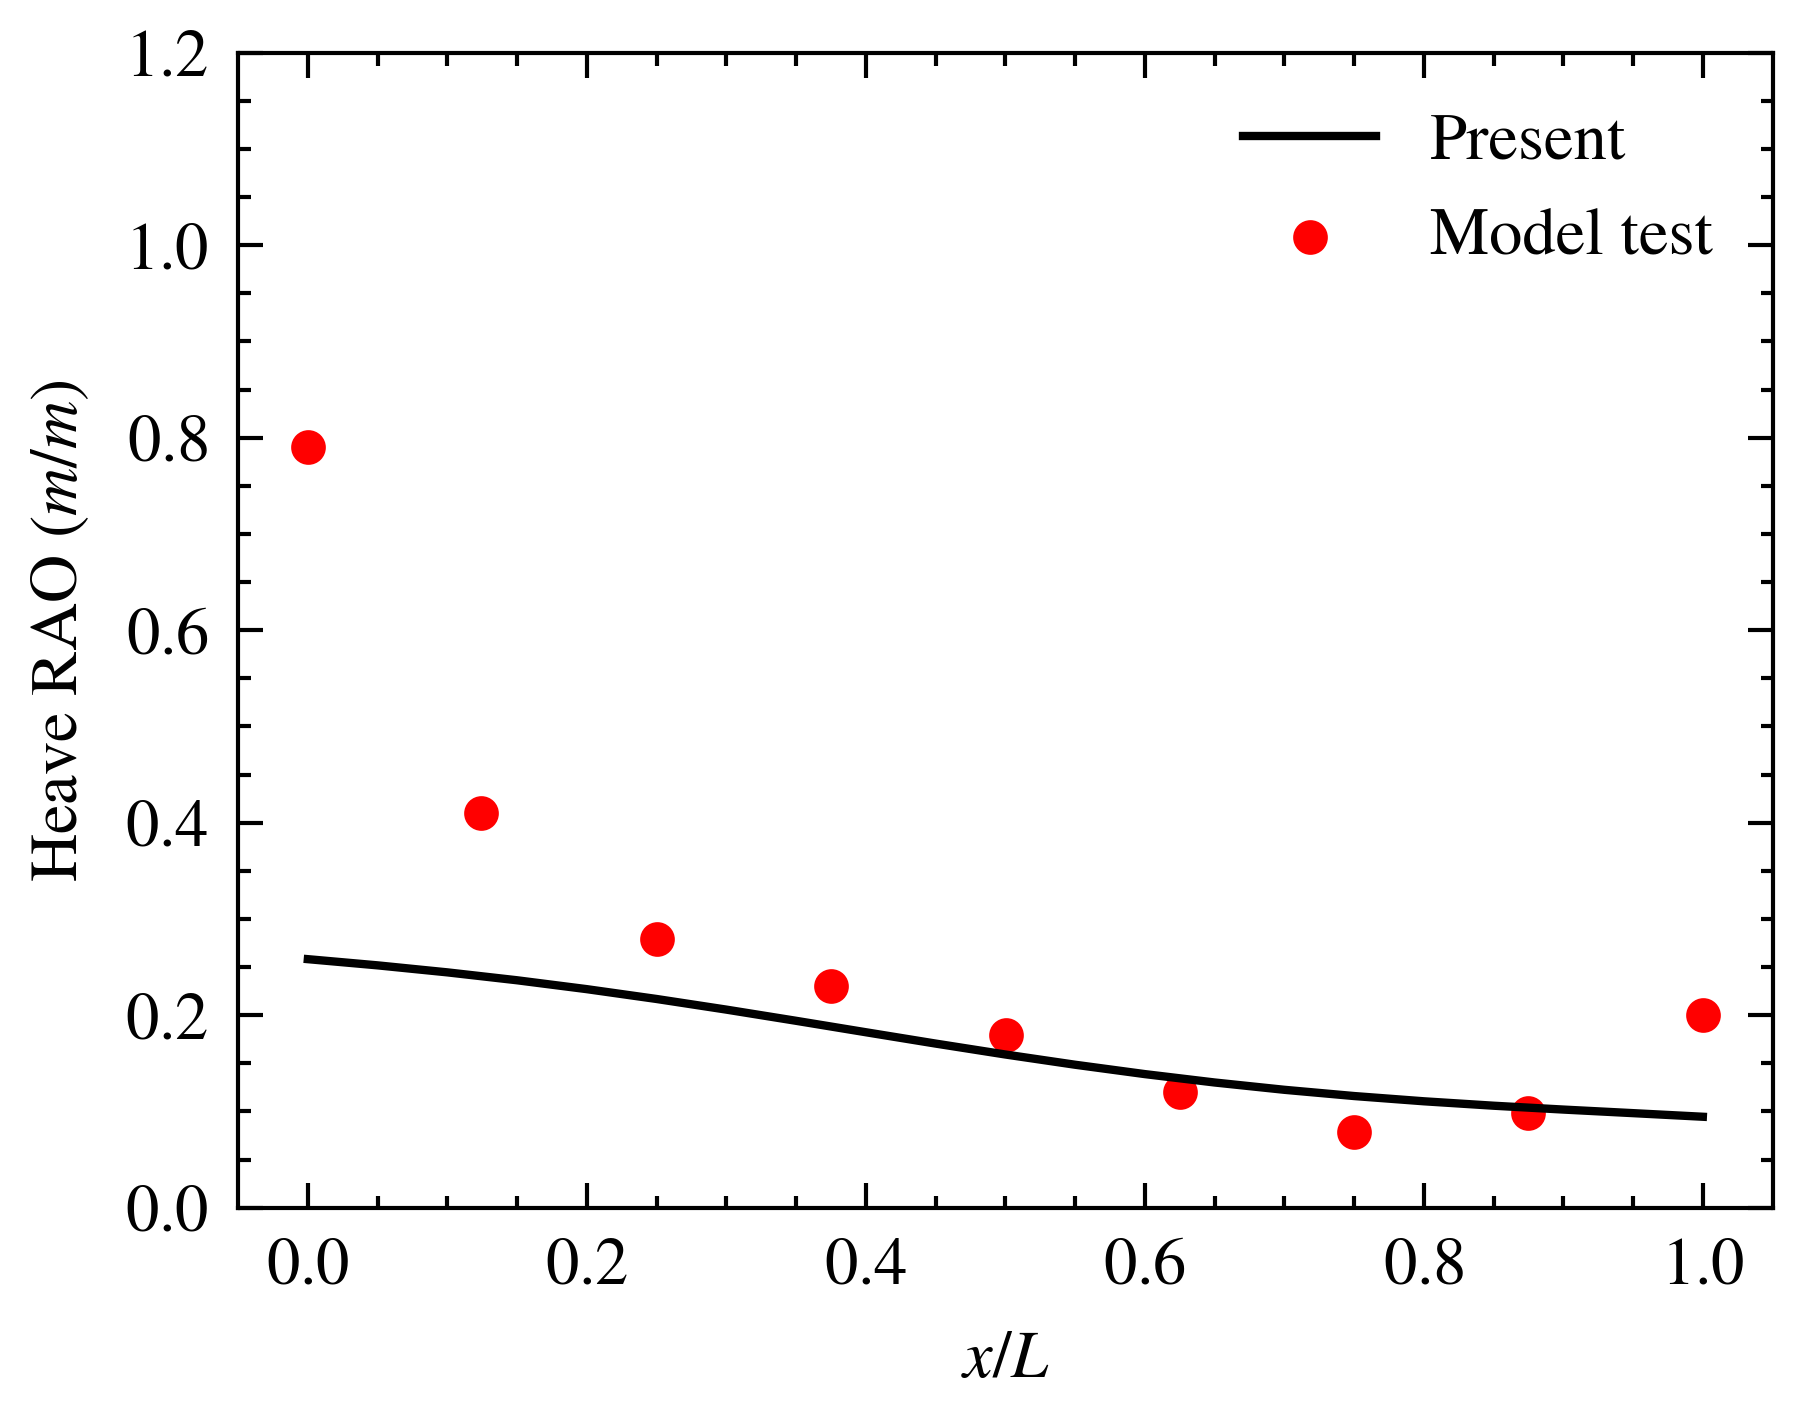

In [62]:
import matplotlib.pyplot as plt
mid = global_displacement[22*5-5:43*5-5,:]
heave = abs(mid[2::5])

# 与实验结果进行对比、绘图
from DM_Verify import process_exp_data
x, y = process_exp_data("E:\phd\Code\DM-FEM2D\data\Experiment_300_60\exp_120.txt")
y = np.array(y)
# 绘图
import scienceplots
x1 = np.linspace(0,1,21)
plt.style.use(['science','no-latex','ieee'])
plt.plot(x1,abs(mid[2::5]), label="Present")
plt.scatter(x,y,color = 'red',label="Model test",s=10)
plt.legend() 
plt.ylim(0,1.2) # 调整y轴坐标
plt.xlabel(r'$x/L$',)
plt.ylabel(r'Heave RAO ($m$/$m$)')

Text(0, 0.5, 'Heave RAO ($m$/$m$)')

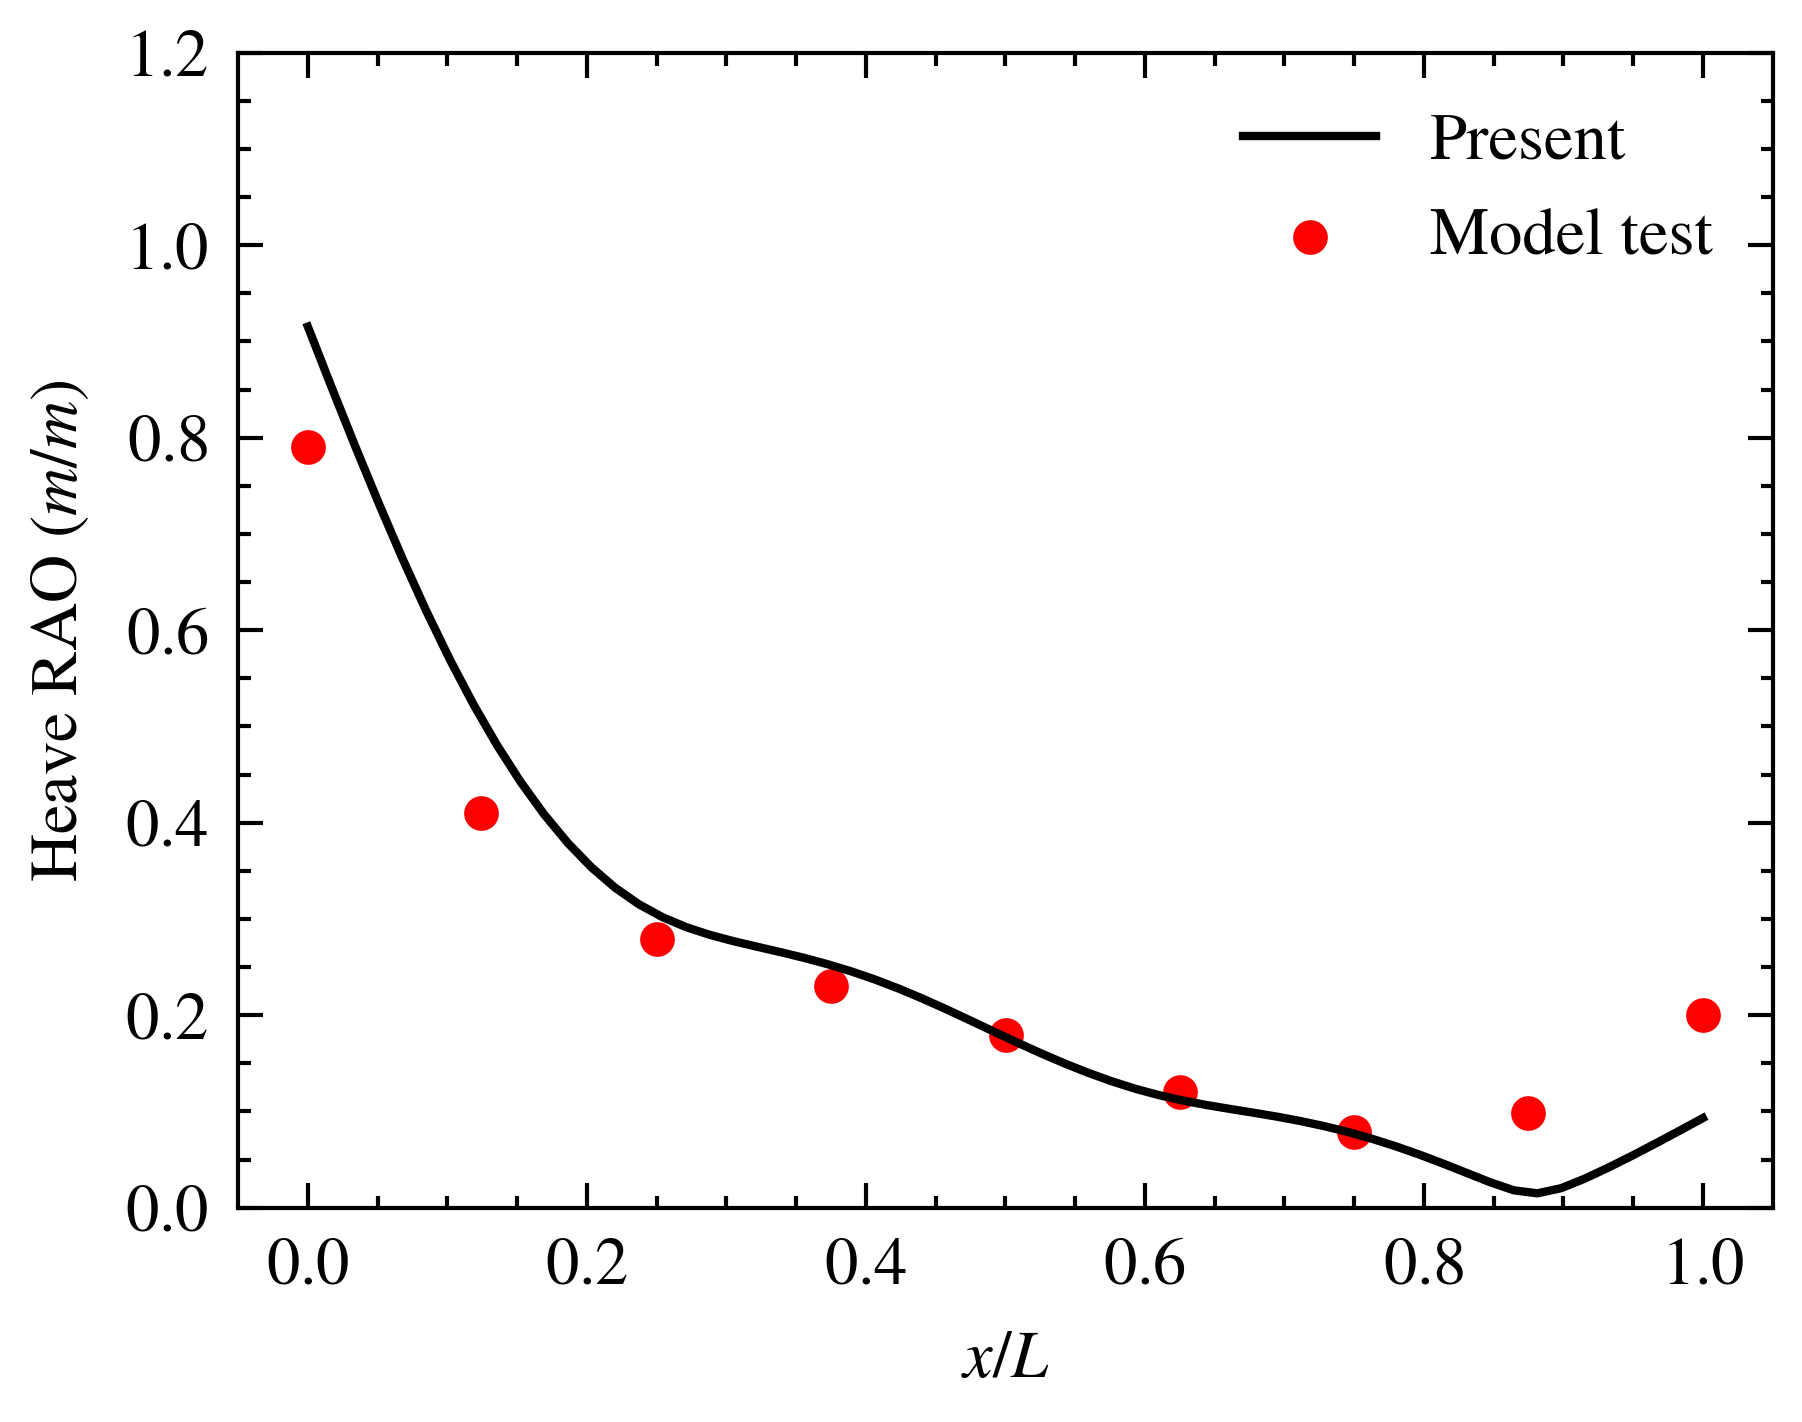

In [63]:
import matplotlib.pyplot as plt
mid = global_displacement[367*5-5:427*5-5,:]
heave = abs(mid[2::5])

# 与实验结果进行对比、绘图
from DM_Verify import process_exp_data
x, y = process_exp_data("E:\phd\Code\DM-FEM2D\data\Experiment_300_60\exp_120.txt")
y = np.array(y)
# 绘图
import scienceplots
x1 = np.linspace(0,1,60)
plt.style.use(['science','no-latex','ieee'])
plt.plot(x1,abs(mid[2::5]), label="Present")
plt.scatter(x,y,color = 'red',label="Model test",s=10)
plt.legend() 
plt.ylim(0,1.2) # 调整y轴坐标
plt.xlabel(r'$x/L$',)
plt.ylabel(r'Heave RAO ($m$/$m$)')